=== Tabel hasil untuk Δt = 0.1 ===
     t  y_numerik   y_eksak  galat_rel
0  0.0   1.000000  1.000000   0.000000
1  0.1   0.833333  0.818731   0.017836
2  0.2   0.694444  0.670320   0.035989
3  0.3   0.578704  0.548812   0.054467
4  0.4   0.482253  0.449329   0.073274
5  0.5   0.401878  0.367879   0.092417
6  0.6   0.334898  0.301194   0.111900
7  0.7   0.279082  0.246597   0.131732
8  0.8   0.232568  0.201897   0.151917
9  0.9   0.193807  0.165299   0.172462

=== Galat relatif di t = 1 ===
Δt = 0.1    → galat relatif di t=1 = 1.933738e-01
Δt = 0.01   → galat relatif di t=1 = 1.993334e-02
Δt = 0.001  → galat relatif di t=1 = 1.999333e-03


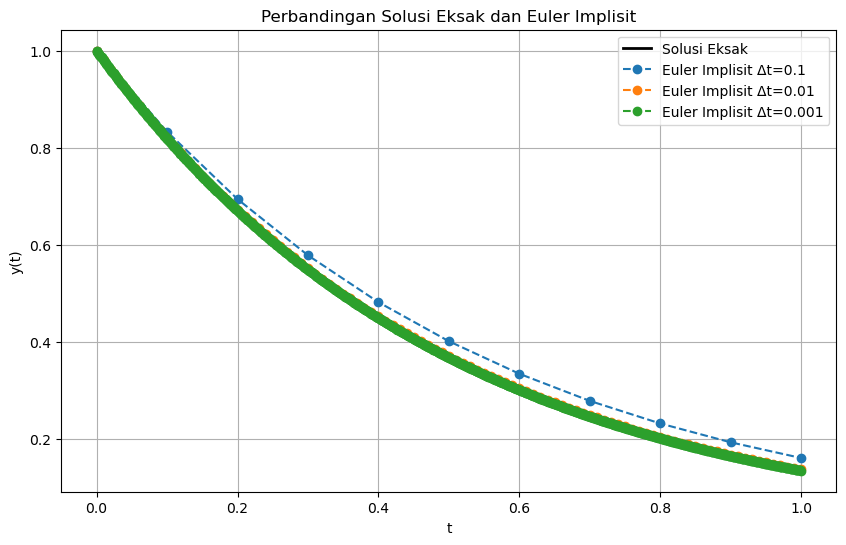

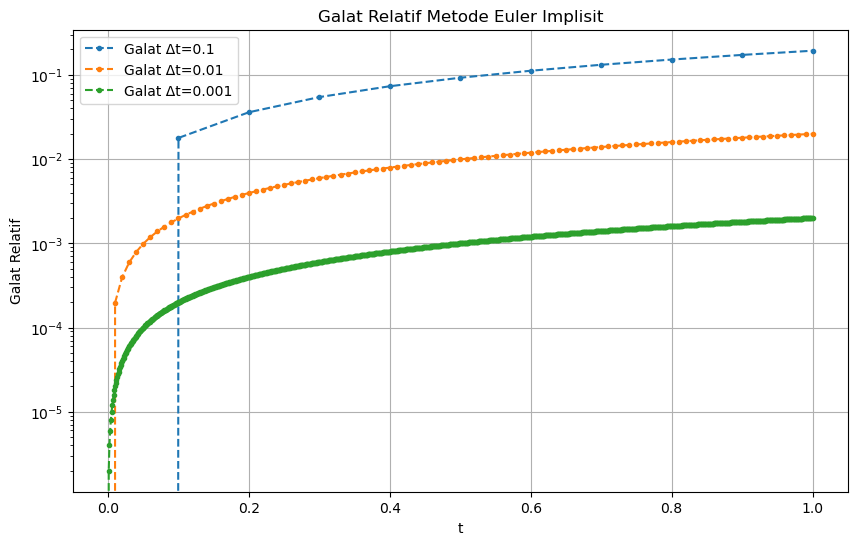

In [1]:
# Latihan 2 - Metode Euler Implisit
# dy/dt = -2y, y(0) = 1
# Solusi eksak: y(t) = e^(-2t)
# Metode beda hingga implisit: y_{n+1} = y_n / (1 + 2Δt)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Solusi eksak ---
def y_exact(t):
    return np.exp(-2 * t)

# --- Metode Euler implisit ---
def euler_implicit(dt, t_end=1):
    N = int(t_end / dt)
    t = np.linspace(0, t_end, N + 1)
    y = np.zeros(N + 1)
    y[0] = 1  # y(0) = 1

    for n in range(N):
        y[n + 1] = y[n] / (1 + 2 * dt)

    return t, y

# --- Hitung untuk Δt = 0.1, 0.01, 0.001 ---
dt_values = [0.1, 0.01, 0.001]
results = {}

for dt in dt_values:
    t, y_num = euler_implicit(dt)
    y_ex = y_exact(t)
    galat_rel = np.abs((y_ex - y_num) / y_ex)
    results[dt] = pd.DataFrame({
        't': t,
        'y_numerik': y_num,
        'y_eksak': y_ex,
        'galat_rel': galat_rel
    })

# --- Tampilkan tabel untuk Δt = 0.1 ---
print("=== Tabel hasil untuk Δt = 0.1 ===")
print(results[0.1].head(10))

# --- Galat di t = 1 ---
print("\n=== Galat relatif di t = 1 ===")
for dt in dt_values:
    galat_t1 = results[dt]['galat_rel'].iloc[-1]
    print(f"Δt = {dt:<6} → galat relatif di t=1 = {galat_t1:.6e}")

# --- Plot hasil ---
plt.figure(figsize=(10,6))
t_exact = np.linspace(0, 1, 1000)
plt.plot(t_exact, y_exact(t_exact), 'k-', label='Solusi Eksak', linewidth=2)

for dt in dt_values:
    plt.plot(results[dt]['t'], results[dt]['y_numerik'], '--o', label=f'Euler Implisit Δt={dt}')

plt.title('Perbandingan Solusi Eksak dan Euler Implisit')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.grid(True)
plt.legend()
plt.show()

# --- Plot galat relatif ---
plt.figure(figsize=(10,6))
for dt in dt_values:
    plt.plot(results[dt]['t'], results[dt]['galat_rel'], marker='.', linestyle='--', label=f'Galat Δt={dt}')
plt.title('Galat Relatif Metode Euler Implisit')
plt.xlabel('t')
plt.ylabel('Galat Relatif')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()
